In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
df.shape

(6607, 20)

In [4]:
df.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [5]:
num_cols = df.select_dtypes(include='number').columns

print("There are", len(num_cols) ," number of columns")
print("The Numerical Columns are: ", list(num_cols))


There are 7  number of columns
The Numerical Columns are:  ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [6]:
calculation = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Variance": df[num_cols].var(),
    "Std Dev": df[num_cols].std(),
    "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})

calculation

,Mean,Median,Mode,Variance,Std Dev,IQR
Hours_Studied,19.975329,20.0,20,35.887221,5.990594,8.0
Attendance,79.977448,80.0,67,133.344178,11.547475,20.0
Sleep_Hours,7.029060,7.0,7,2.155377,1.468120,2.0
Previous_Scores,75.070531,75.0,66,207.353789,14.399784,25.0
Tutoring_Sessions,1.493719,1.0,1,1.514304,1.230570,1.0
Physical_Activity,2.967610,3.0,3,1.063438,1.031231,2.0
Exam_Score,67.235659,67.0,68,15.135646,3.890456,4.0


<Figure size 640x480 with 0 Axes>

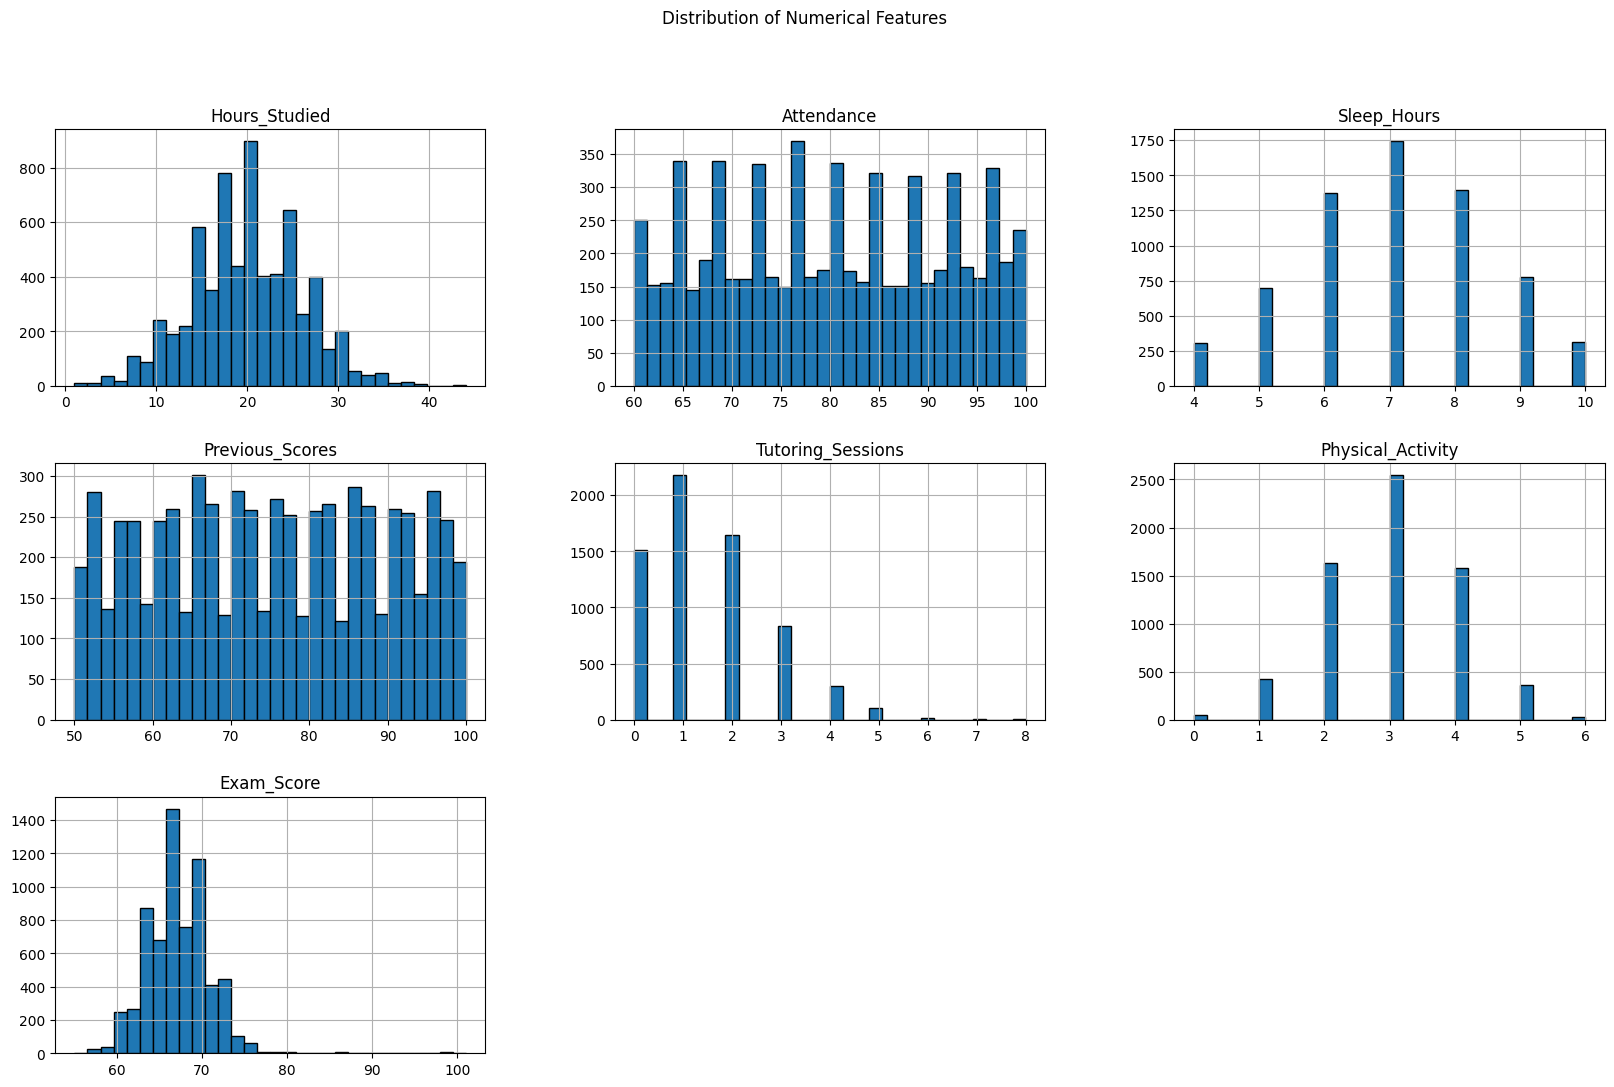

In [7]:
plt.figure()

df[num_cols].hist(bins =30,edgecolor = 'black',figsize=(20,12))
plt.suptitle("Distribution of Numerical Features")
plt.show()



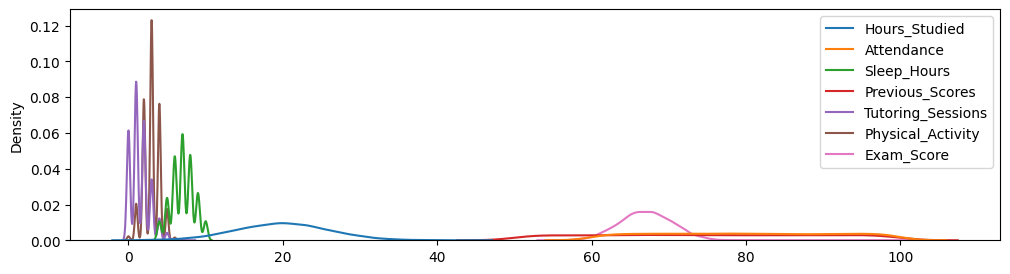

In [8]:
plt.figure(figsize = (12,3))
sns.kdeplot(df[num_cols])
plt.show()

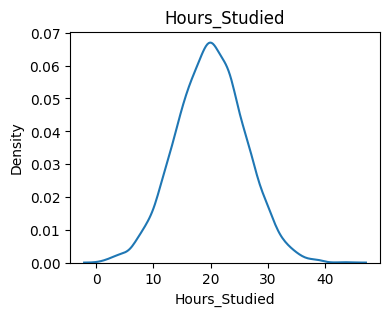

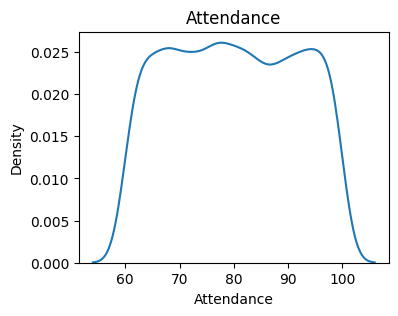

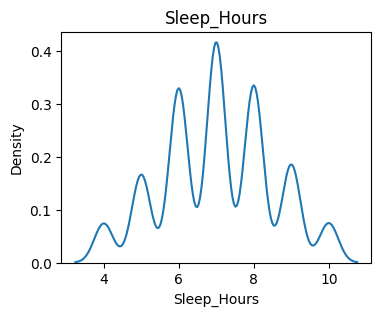

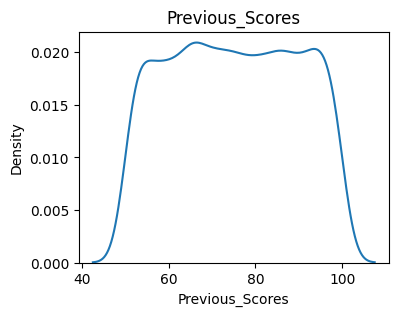

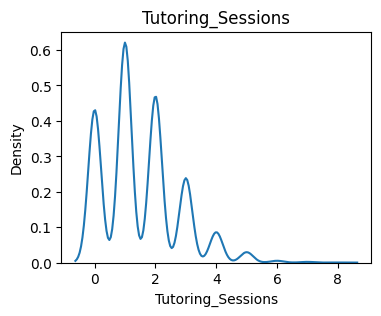

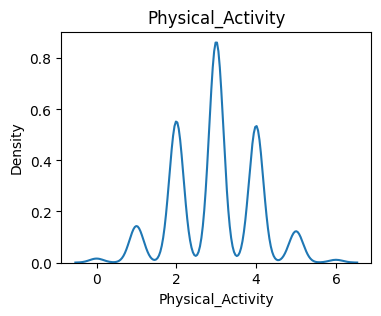

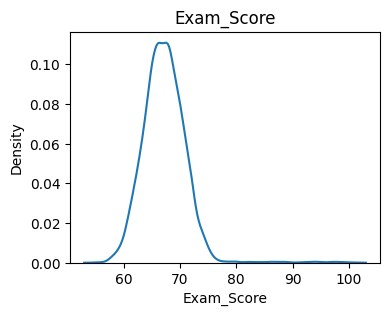

In [9]:
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.kdeplot(df[col])
    plt.title(col)
    plt.show()

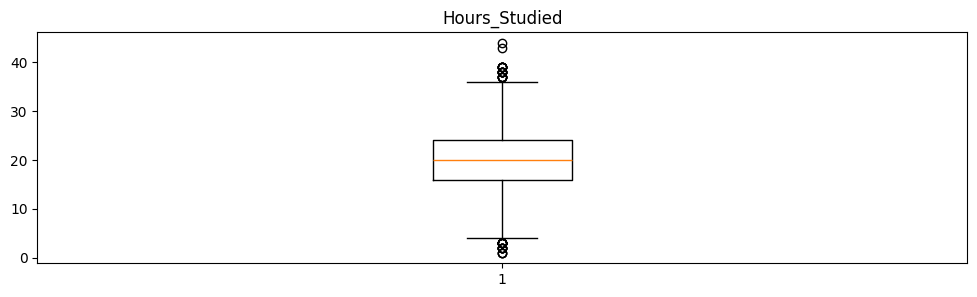

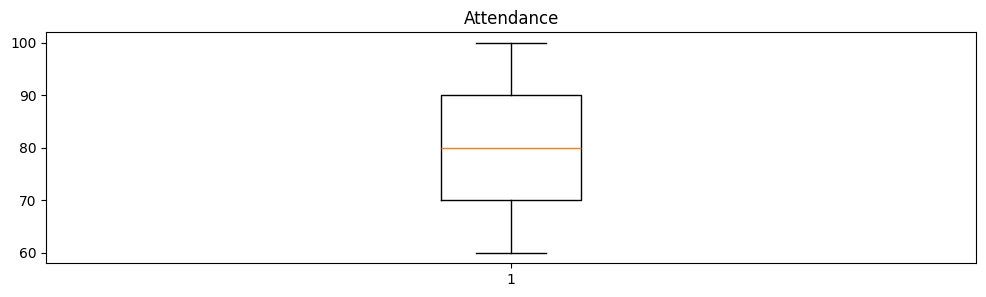

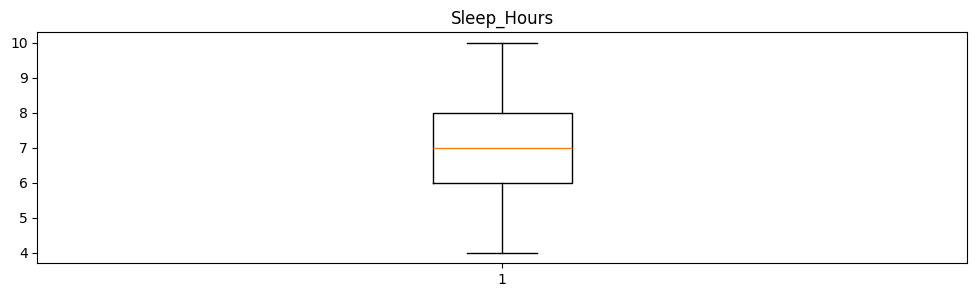

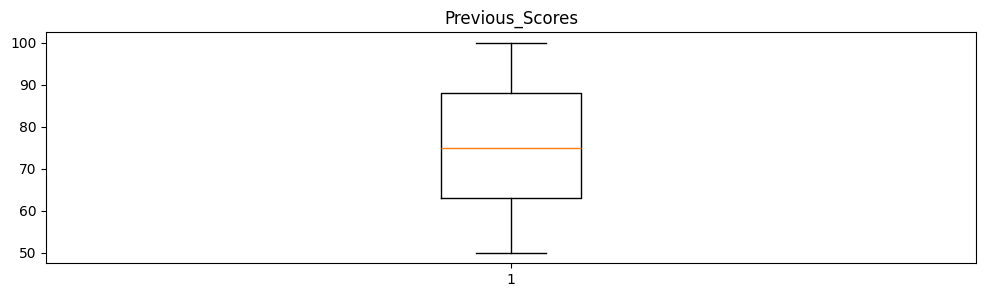

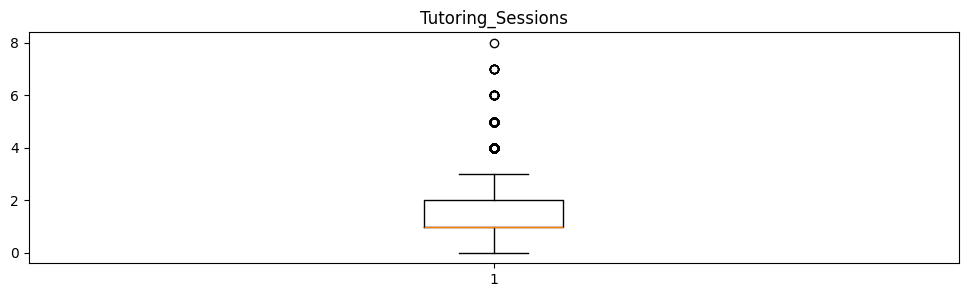

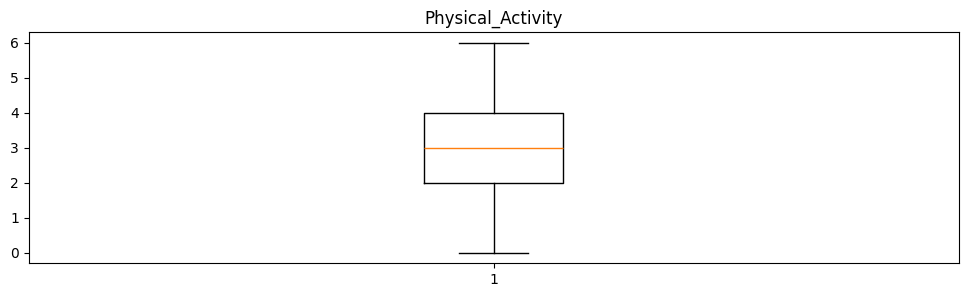

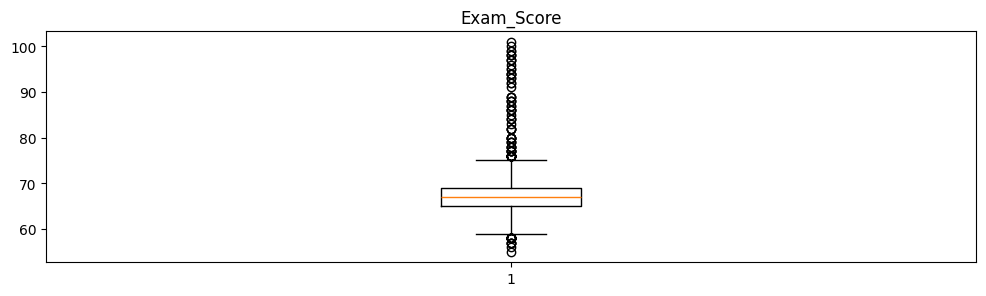

In [10]:
for col in num_cols:
    plt.figure(figsize=(12,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [11]:
cat_cols = df.select_dtypes(include=['object','string']).columns

print("There are ", len(cat_cols)," categorical features")
print("The Categorical Columns are: ", list(cat_cols))



There are  13  categorical features
The Categorical Columns are:  ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [31]:
for col in cat_cols:
    print(f"Frequency Table for: {col}")
    
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = ['Category', 'Count']
  
    print(freq_table.to_string(index=False))

Frequency Table for: Parental_Involvement
Category  Count
  Medium   3362
    High   1908
     Low   1337
Frequency Table for: Access_to_Resources
Category  Count
  Medium   3319
    High   1975
     Low   1313
Frequency Table for: Extracurricular_Activities
Category  Count
     Yes   3938
      No   2669
Frequency Table for: Motivation_Level
Category  Count
  Medium   3351
     Low   1937
    High   1319
Frequency Table for: Internet_Access
Category  Count
     Yes   6108
      No    499
Frequency Table for: Family_Income
Category  Count
     Low   2672
  Medium   2666
    High   1269
Frequency Table for: Teacher_Quality
Category  Count
  Medium   3925
    High   1947
     Low    657
Frequency Table for: School_Type
Category  Count
  Public   4598
 Private   2009
Frequency Table for: Peer_Influence
Category  Count
Positive   2638
 Neutral   2592
Negative   1377
Frequency Table for: Learning_Disabilities
Category  Count
      No   5912
     Yes    695
Frequency Table for: Parental_Educ

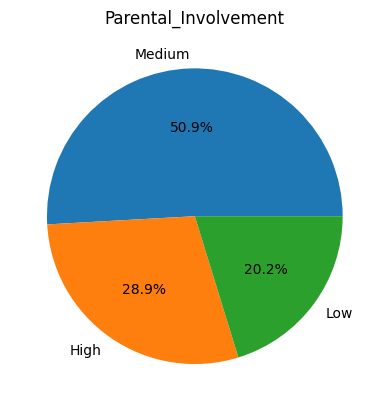

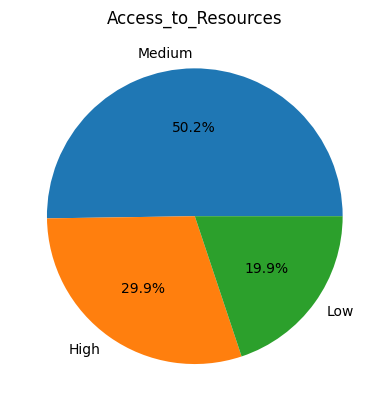

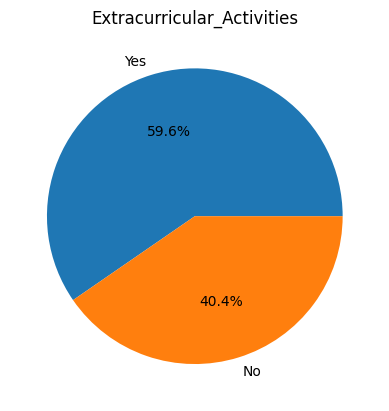

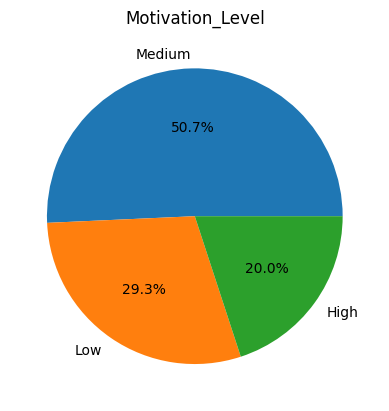

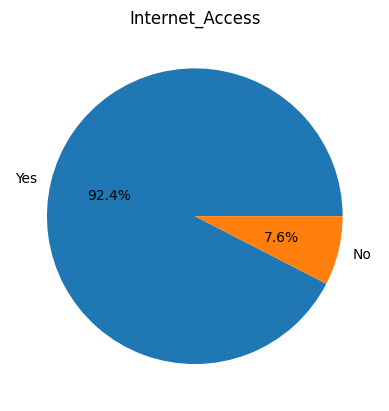

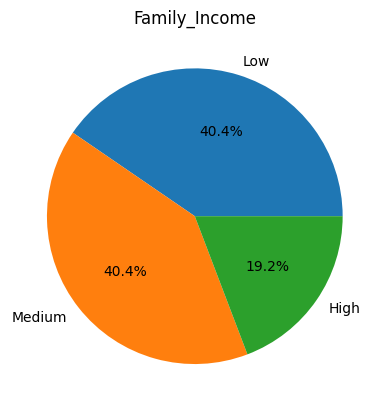

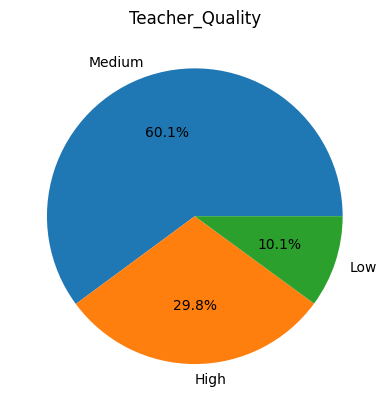

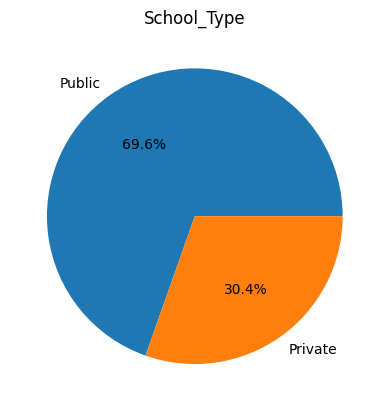

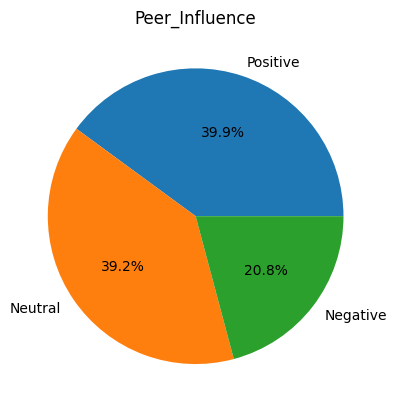

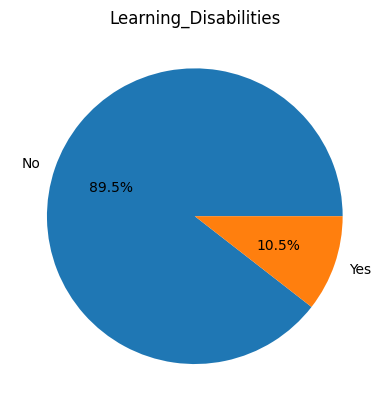

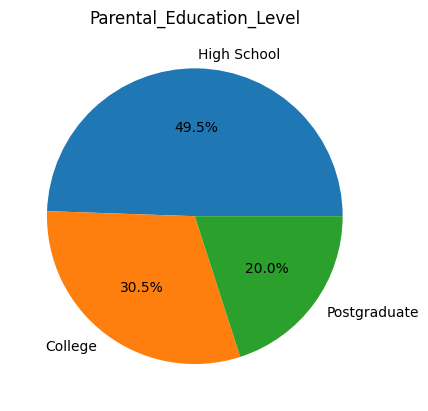

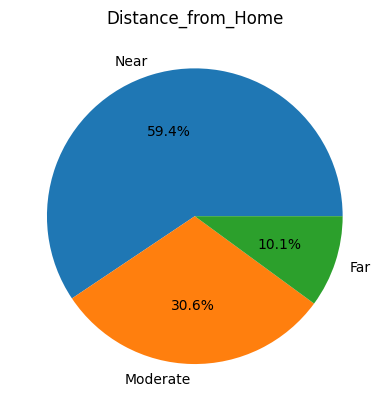

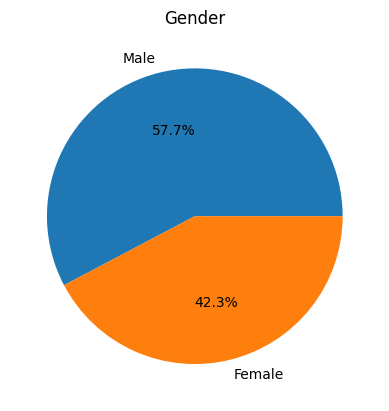

In [39]:
for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(col)
    plt.show()

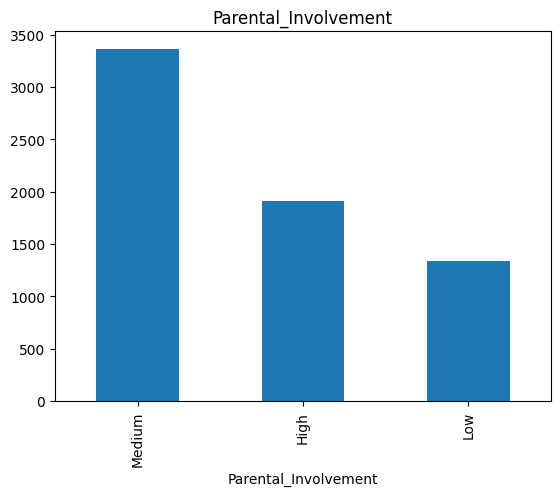

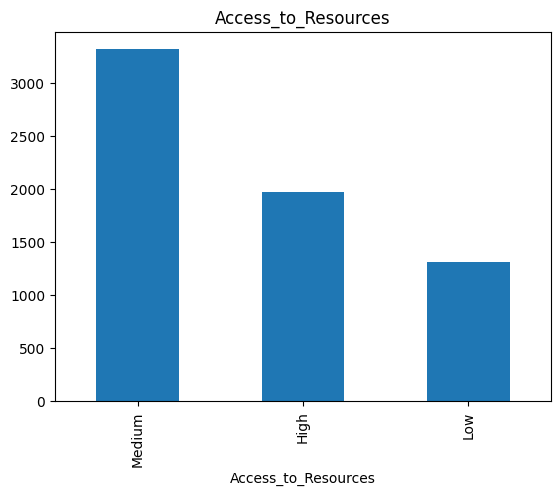

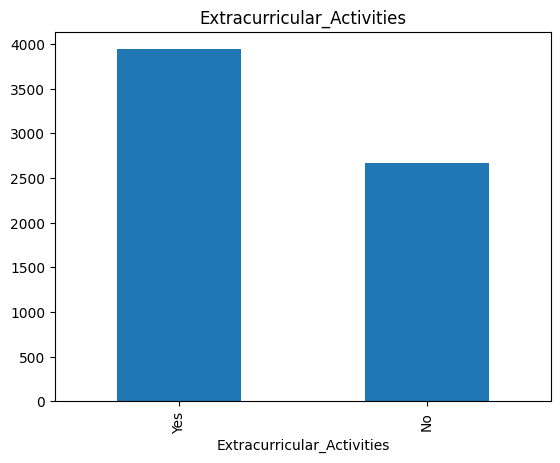

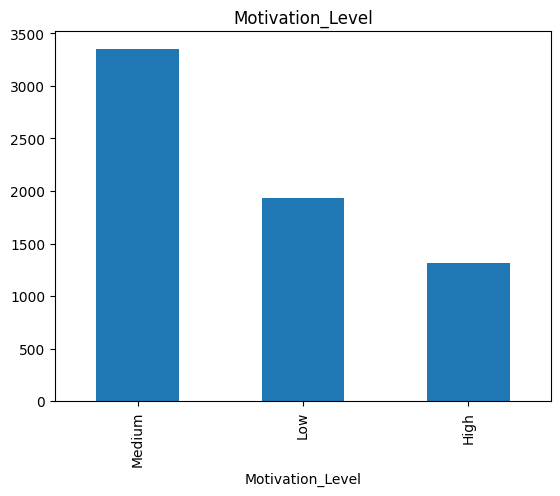

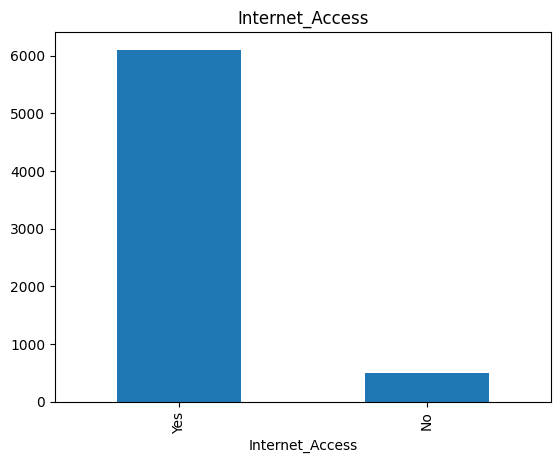

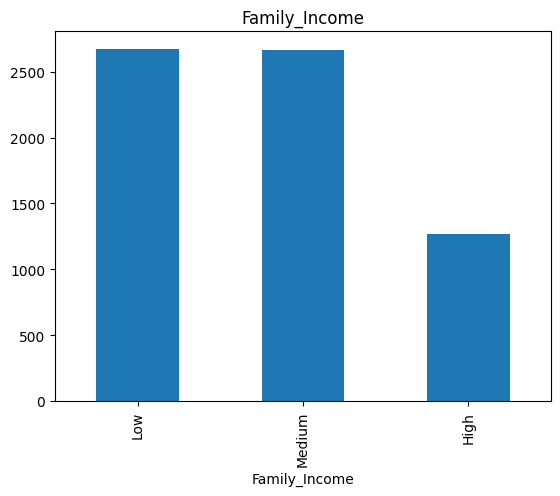

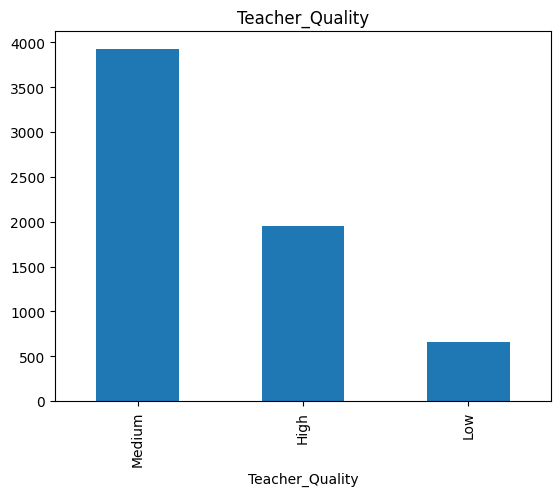

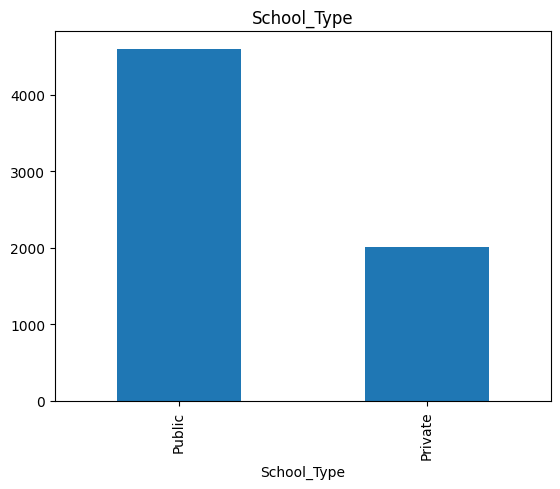

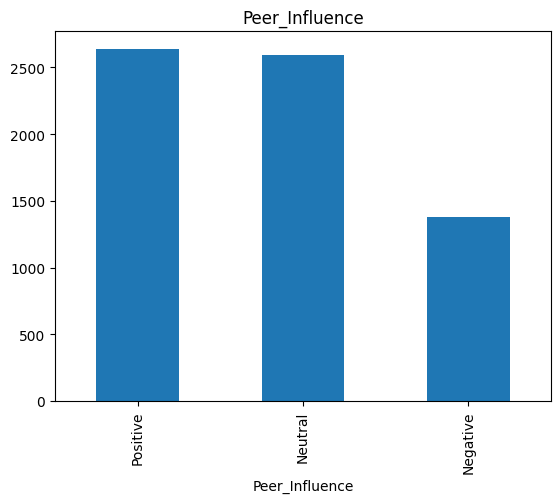

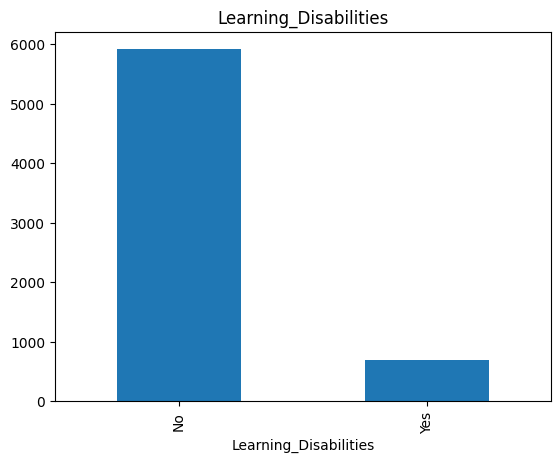

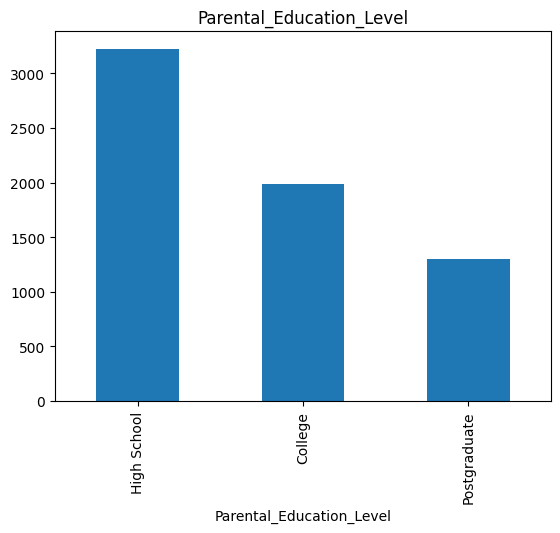

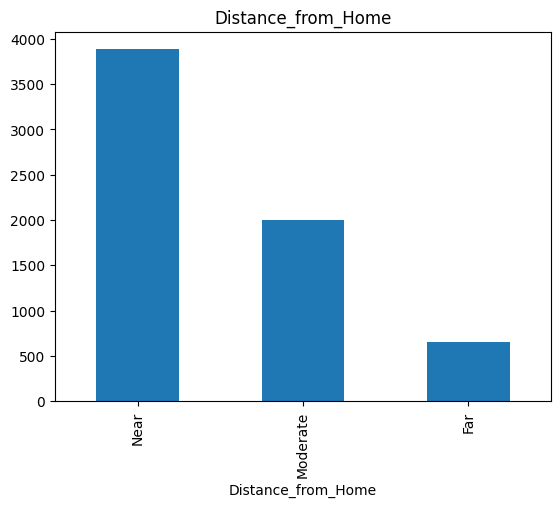

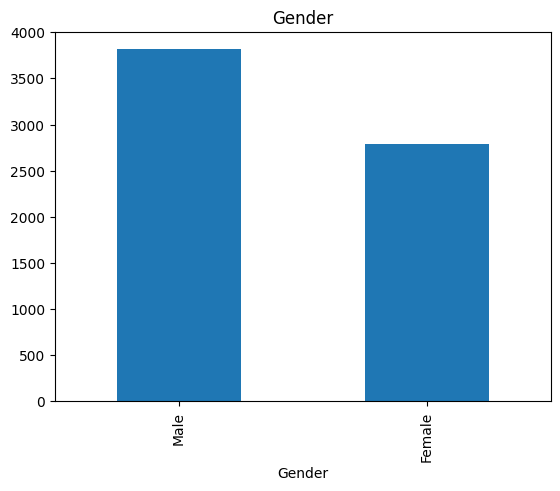

In [14]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

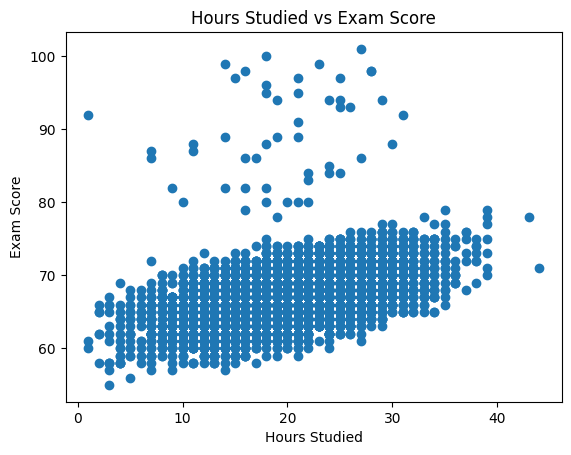

In [41]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

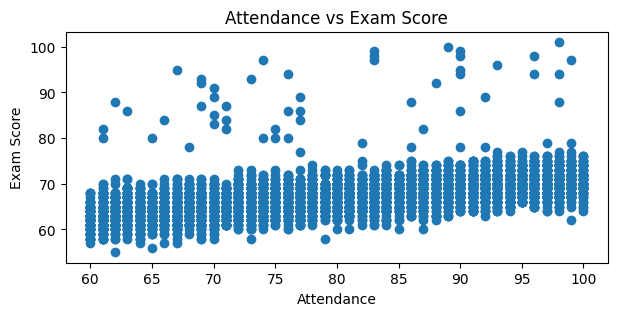

In [50]:
plt.figure(figsize=(7,3))
plt.scatter(df['Attendance'],df['Exam_Score'])
plt.xlabel('Attendance')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score')
plt.show()

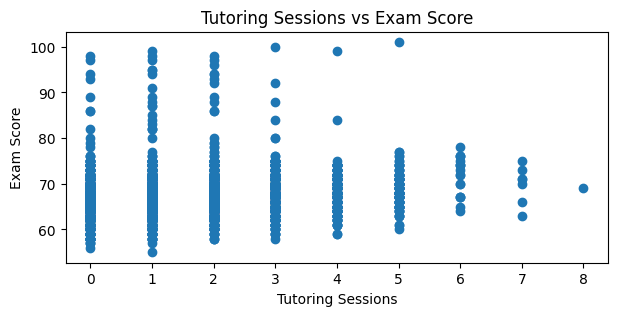

In [54]:
plt.figure(figsize=(7,3))
plt.scatter(df['Tutoring_Sessions'], df['Exam_Score'])
plt.xlabel('Tutoring Sessions')
plt.ylabel('Exam Score')
plt.title('Tutoring Sessions vs Exam Score')
plt.show()

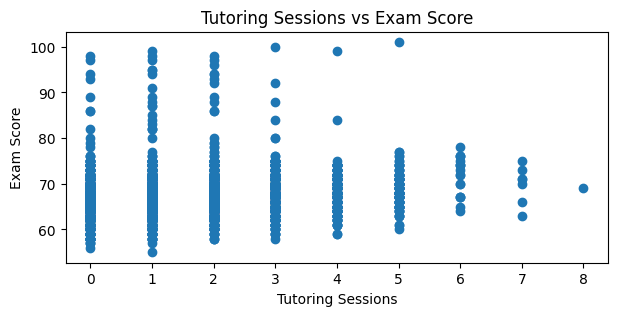

In [55]:
plt.figure(figsize=(7,3))
plt.scatter(df['Tutoring_Sessions'], df['Exam_Score'])
plt.xlabel('Tutoring Sessions')
plt.ylabel('Exam Score')
plt.title('Tutoring Sessions vs Exam Score')
plt.show()

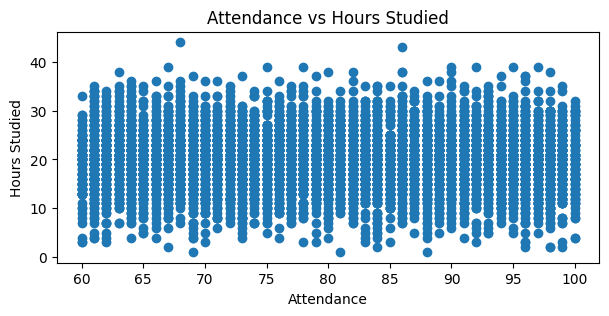

In [56]:
plt.figure(figsize=(7,3))
plt.scatter(df['Attendance'], df['Hours_Studied'])
plt.xlabel('Attendance')
plt.ylabel('Hours Studied')
plt.title('Attendance vs Hours Studied')
plt.show()

In [58]:
num_cols

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='str')

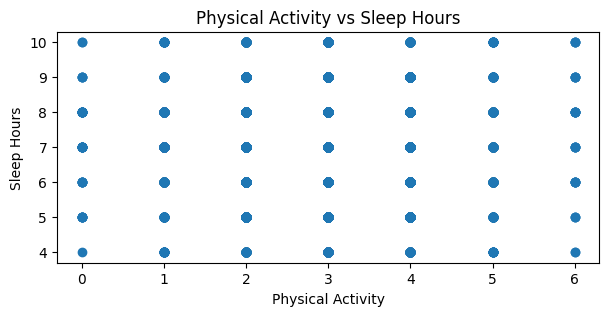

In [59]:
plt.figure(figsize=(7,3))
plt.scatter(df['Physical_Activity'], df['Sleep_Hours'])
plt.xlabel('Physical Activity')
plt.ylabel('Sleep Hours')
plt.title('Physical Activity vs Sleep Hours')
plt.show()

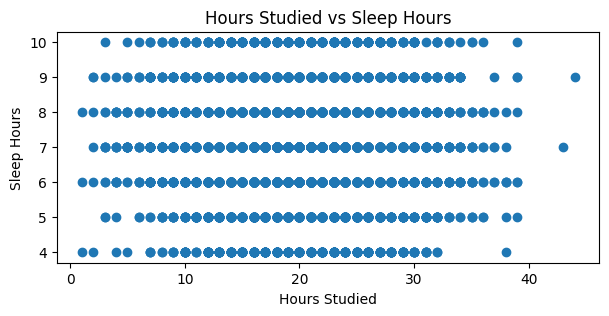

In [60]:
plt.figure(figsize=(7,3))
plt.scatter(df['Hours_Studied'], df['Sleep_Hours'])
plt.xlabel('Hours Studied')
plt.ylabel('Sleep Hours')
plt.title('Hours Studied vs Sleep Hours')
plt.show()

In [61]:
df.isnull().sum().sum()


np.int64(235)

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.drop_duplicates(inplace=True)